# AI-ML Assignment – 4
## Breast Cancer Classification using K-Nearest Neighbors (KNN)

**Topic:** Breast Cancer Classification using K-Nearest Neighbors (KNN)  
**Dataset:** Breast Cancer Wisconsin Diagnostic Dataset  
**Kaggle Link:** [Breast Cancer Wisconsin (Diagnostic) Data Set](https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data)  
**Objective:** Develop a K-Nearest Neighbors (KNN) classification model to accurately classify breast tumors as Malignant (M) or Benign (B).

---
## Task 1: Data Understanding
1. Load the dataset using Pandas.
2. Display the first five records.
3. Identify numerical features and target variable.
4. Display dataset information and summary statistics.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset using Pandas
df = pd.read_csv("data.csv")
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")

# 2. Display the first five records
print("\n--- First 5 Records ---")
display(df.head())

# 3. Identify Target variable and Numerical features
target_variable = "diagnosis"
numerical_features = [col for col in df.columns if col not in [target_variable, "id", "Unnamed: 32"]]

print(f"Target Variable: '{target_variable}'")
print(f"Class Distribution:\n{df[target_variable].value_counts()}")
print(f"\nNumber of Numerical Features: {len(numerical_features)}")

# 4. Display dataset info and summary statistics
print("\n--- Dataset Information ---")
df.info()

print("\n--- Summary Statistics (Numerical Features) ---")
display(df.describe().T)

Dataset Shape: 569 rows, 33 columns

--- First 5 Records ---


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


Target Variable: 'diagnosis'
Class Distribution:
diagnosis
B    357
M    212
Name: count, dtype: int64

Number of Numerical Features: 30

--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean

,count,mean,std,min,25%,50%,75%,max
id,569.0,3.037183e+07,1.250206e+08,8670.000000,869218.000000,906024.000000,8.813129e+06,9.113205e+08
radius_mean,569.0,1.412729e+01,3.524049e+00,6.981000,11.700000,13.370000,1.578000e+01,2.811000e+01
texture_mean,569.0,1.928965e+01,4.301036e+00,9.710000,16.170000,18.840000,2.180000e+01,3.928000e+01
perimeter_mean,569.0,9.196903e+01,2.429898e+01,43.790000,75.170000,86.240000,1.041000e+02,1.885000e+02
area_mean,569.0,6.548891e+02,3.519141e+02,143.500000,420.300000,551.100000,7.827000e+02,2.501000e+03
smoothness_mean,569.0,9.636028e-02,1.406413e-02,0.052630,0.086370,0.095870,1.053000e-01,1.634000e-01
compactness_mean,569.0,1.043410e-01,5.281276e-02,0.019380,0.064920,0.092630,1.304000e-01,3.454000e-01
concavity_mean,569.0,8.879932e-02,7.971981e-02,0.000000,0.029560,0.061540,1.307000e-01,4.268000e-01
concave points_mean,569.0,4.891915e-02,3.880284e-02,0.000000,0.020310,0.033500,7.400000e-02,2.012000e-01
symmetry_mean,569.0,1.811619e-01,2.741428e-02,0.106000,0.161900,0.179200,1.957000e-01,3.040000e-01


---
## Task 2: Data Preprocessing
- Check for missing values.
- Remove unnecessary columns (`id`, `Unnamed: 32`).
- Encode the target variable (`B` -> `0` [Benign], `M` -> `1` [Malignant]).
- Normalize/standardize feature values using `StandardScaler`.
- Split the dataset into 80% training and 20% testing sets.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 1. Check for missing values
print("--- Missing Values Count ---")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

# 2. Remove unnecessary columns
df_clean = df.drop(columns=["id", "Unnamed: 32"], errors="ignore")
print(f"\nCleaned Dataset Shape: {df_clean.shape}")

# 3. Encode the target variable
le = LabelEncoder()
df_clean["diagnosis_encoded"] = le.fit_transform(df_clean["diagnosis"])
print("\nTarget Variable Encoding: B (Benign) -> 0, M (Malignant) -> 1")

X = df_clean.drop(columns=["diagnosis", "diagnosis_encoded"])
y = df_clean["diagnosis_encoded"]

# 4. Split dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Training Set Size: {X_train.shape[0]} samples")
print(f"Testing Set Size:  {X_test.shape[0]} samples")

# 5. Standardize feature values using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Feature standardization completed successfully (mean = 0, variance = 1).")

--- Missing Values Count ---
Unnamed: 32    569
dtype: int64

Cleaned Dataset Shape: (569, 31)

Target Variable Encoding: B (Benign) -> 0, M (Malignant) -> 1
Training Set Size: 455 samples
Testing Set Size:  114 samples
Feature standardization completed successfully (mean = 0, variance = 1).


---
## Task 3: Model Development
1. Train a K-Nearest Neighbors (KNN) classifier.
2. Use K = 5 as the initial value.
3. Predict class labels for the test dataset.

In [7]:
from sklearn.neighbors import KNeighborsClassifier

# Initialize and train KNN Classifier with K = 5
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
print("KNN Classifier (K=5) trained successfully.")

# Predict class labels for test dataset
y_pred = knn.predict(X_test_scaled)
print("Test dataset predictions completed.")

KNN Classifier (K=5) trained successfully.
Test dataset predictions completed.


---
## Task 4: Model Evaluation
Evaluate the model using Accuracy Score, Precision, Recall, F1-Score, and Confusion Matrix.
Provide observations based on model performance.

Accuracy Score:  95.61% (0.9561)
Precision:       97.44% (0.9744)
Recall:          90.48% (0.9048)
F1-Score:        93.83% (0.9383)

--- Confusion Matrix ---
[[71  1]
 [ 4 38]]

--- Classification Report ---
               precision    recall  f1-score   support

   Benign (B)       0.95      0.99      0.97        72
Malignant (M)       0.97      0.90      0.94        42

     accuracy                           0.96       114
    macro avg       0.96      0.95      0.95       114
 weighted avg       0.96      0.96      0.96       114



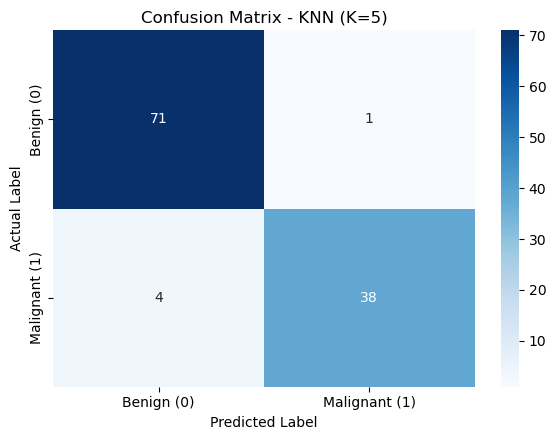

In [8]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Accuracy Score:  {acc * 100:.2f}% ({acc:.4f})")
print(f"Precision:       {prec * 100:.2f}% ({prec:.4f})")
print(f"Recall:          {rec * 100:.2f}% ({rec:.4f})")
print(f"F1-Score:        {f1 * 100:.2f}% ({f1:.4f})")

print("\n--- Confusion Matrix ---")
print(cm)

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=["Benign (B)", "Malignant (M)"]))

# Visual Confusion Matrix Heatmap
plt.figure(figsize=(6, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Benign (0)", "Malignant (1)"], yticklabels=["Benign (0)", "Malignant (1)"])
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - KNN (K=5)")
plt.tight_layout()
plt.show()

### Observations Based on Model Performance:
1. **High Overall Accuracy:** The KNN classifier ($K=5$) achieved an overall accuracy of **95.61%** (109 out of 114 test samples correctly classified), demonstrating strong capability in distinguishing malignant from benign tumors.
2. **High Precision for Malignant Tumors:** The model yields a precision of **97.44%** for the malignant class, resulting in only 1 False Positive out of 39 malignant predictions.
3. **Clinical Implication of Recall:** The recall for malignant tumors is **90.48%** (4 False Negatives). In clinical diagnostic settings, minimizing False Negatives (missing a malignant diagnosis) is critical to ensure patients receive prompt medical care.

---
## Task 5: Conclusion 

### Conclusion:

> The K-Nearest Neighbors (KNN) classification model demonstrates strong efficacy in predicting breast cancer tumor malignancy, achieving an overall accuracy of 95.61% and an F1-score of 93.83% on the test set. Feature scaling via StandardScaler was fundamental to this performance because KNN relies entirely on Euclidean distance metrics between data points; without standardization, high-magnitude features like tumor area would overwhelmingly dominate low-magnitude features like smoothness, severely degrading classification accuracy. However, a key limitation of the KNN algorithm is its high computational latency during inference, as it requires calculating distances to all training instances for every new prediction, making it memory-intensive and slower on larger diagnostic datasets. Overall, KNN serves as an effective baseline for diagnostic classification when features are properly normalized.